In [1]:
import os
import math
import json
import copy
import itertools
import functools
from datetime import datetime

In [2]:
os.environ.setdefault("FINTORCH_BASE_TIME_FRAME", "60")

'60'

In [3]:
import numpy as np
from rich.progress import Progress

from fintorch.enum import TimeFrame
from fintorch.exchange import ONLINE_EXCHANGE
from fintorch.setting import RICH_PROGRESS_COLUMNS
from fintorch.utils.function import call_with_dict
from fintorch.utils.args import DefaultArgumentParser
from fintorch.deep.transform.label import ForwardRocLabelTransform

In [100]:
string_args = [
    "--stop-date", "2024-06-01",
    "--symbol", "XRP-USDT",
    "--time-frame", "60",
]
args = DefaultArgumentParser.parse(args=string_args)

In [ ]:
with Progress(*RICH_PROGRESS_COLUMNS) as progress:
    ONLINE_EXCHANGE.future.data.update_candles_dataframe(symbol=args.symbol, time_frame=args.time_frame, progress=progress)

Output()

In [11]:
dc = ONLINE_EXCHANGE.future.data.get_data_collection(symbols=[args.symbol], time_frames=[args.time_frame])
sdf = ONLINE_EXCHANGE.future.data.get_candles_dataframe(symbol=args.symbol, time_frame=args.time_frame).copy()

sdf.insert(0, "datetime", [datetime.fromtimestamp(ts) for ts in sdf.index.to_list()])

sdf

,datetime,open,high,low,close,volume,trade
timestamp,,,,,,,
1569398400,2019-09-25 11:30:00,8325.28,8330.36,8320.85,8322.44,18.796,55
1569398460,2019-09-25 11:31:00,8329.93,8329.93,8292.16,8307.37,51.096,168
1569398520,2019-09-25 11:32:00,8308.14,8308.16,8279.93,8301.24,122.686,251
1569398580,2019-09-25 11:33:00,8296.89,8313.61,8271.86,8275.98,122.719,226
1569398640,2019-09-25 11:34:00,8276.08,8293.35,8270.93,8290.86,108.744,213
...,...,...,...,...,...,...,...
1710016860,2024-03-10 00:11:00,68392.20,68392.30,68378.60,68378.90,30.364,651
1710016920,2024-03-10 00:12:00,68378.90,68384.40,68357.70,68370.50,73.236,1147
1710016980,2024-03-10 00:13:00,68370.50,68370.60,68356.20,68361.00,11.740,427


In [28]:
label_transform = call_with_dict(ForwardRocLabelTransform, args.transform_kwargs)
ldf = label_transform.transform_df(dc=dc)

ldf

,open,high,low,close,volume,trade,roc,sum-roc,forward-sum-roc,label
timestamp,,,,,,,,,,
1569398400,8325.28,8330.36,8320.85,8322.44,18.796,55,-0.000341,-0.000341,0.003561,True
1569398460,8329.93,8329.93,8292.16,8307.37,51.096,168,-0.002708,-0.003049,0.005127,True
1569398520,8308.14,8308.16,8279.93,8301.24,122.686,251,-0.000831,-0.003880,0.006752,True
1569398580,8296.89,8313.61,8271.86,8275.98,122.719,226,-0.002520,-0.006400,0.008236,True
1569398640,8276.08,8293.35,8270.93,8290.86,108.744,213,0.001786,-0.004614,0.008036,True
...,...,...,...,...,...,...,...,...,...,...
1710016860,68392.20,68392.30,68378.60,68378.90,30.364,651,-0.000194,0.000138,0.000163,True
1710016920,68378.90,68384.40,68357.70,68370.50,73.236,1147,-0.000123,0.000142,0.000163,True
1710016980,68370.50,68370.60,68356.20,68361.00,11.740,427,-0.000139,0.000350,0.000163,True


In [99]:
LENGTH = 5
LOOKAHEAD = 20
TAKE_PROFIT_MULT = 1

# indicators
df = sdf.copy()
df["tr"] = df.high / df.low - 1
df["roc"] = df.close / df.open - 1
df["atr"] = df.tr.rolling(window=LENGTH).mean()
df["aroc"] = np.abs(df.roc).rolling(window=LENGTH).mean()

df["csroc"] = np.cumsum(df.roc)
df["bbm"] = df.csroc.rolling(window=LENGTH).mean()
df["bbs"] = df.csroc.rolling(window=LENGTH).std()
df["bbl"] = df.bbm - df.bbs
df["bbh"] = df.bbm + df.bbs

df["bmax"] = df.csroc.rolling(window=LENGTH).max()
df["bmin"] = df.csroc.rolling(window=LENGTH).min()
df["distmax"] = np.abs(df.bmax - df.csroc)
df["distmin"] = np.abs(df.bmin - df.csroc)
df["farmax"] = df.distmax.mean() + df.distmax.std() <= df.distmax
df["farmin"] = df.distmin.mean() + df.distmin.std() <= df.distmin
df["closemax"] = df.distmax <= df.distmax.mean() + df.distmax.std()
df["closemin"] = df.distmin <= df.distmin.mean() + df.distmin.std()

# buy signals                               # WINING RATIO | DAILY PROFIT (LENGTH = 5, LOOKAHEAD = 10, TAKE_PROFIT_MULT = 1)
# df["buy"] = True                          # 77.56 | 0.83
# df["buy"] = df.bbs < df.atr               # 78.16 | 0.74
# df["buy"] = df.closemax                   # 79.18 | 0.66
# df["buy"] = df.bbm < df.csroc             # 87.47 | 0.42
df["buy"] = ldf.label                     # 90.37 | 0.42
# df["buy"] = df.bbh < df.csroc             # 96.59 | 0.18

# take profit 
# df["tp"] = TAKE_PROFIT_MULT * df.atr
df["tp"] = TAKE_PROFIT_MULT * df.aroc

# backetst
df["buy"] = df.buy & (0.001 <= df.aroc)
df["tp"] = np.clip(df.tp, 0, 0.01)

df["fmax"] = df.high.rolling(window=LOOKAHEAD).max().shift(periods=-LOOKAHEAD + 1) / df.open - 1
df["pnl"] = np.where(df.buy, df.fmax, 0)
df["profitable"] = df.tp <= df.pnl
df = df.dropna()

# metrics
bdf = df[df.buy]

candles_in_day = TimeFrame.DAY1 // TimeFrame.MIN1
days = len(df) // candles_in_day
buy_rate = round(len(bdf) / len(df) * 100, 2)
buy_singals = len(bdf)
daily_buy_singals = round(len(bdf) / days, 1)
daily_net_profit = round(bdf.tp.sum() / days, 2)

wining_ratio = round(bdf.profitable.sum() / len(bdf) * 100, 2)
net_profit = round(bdf.tp.sum(), 2)
mean_profit = round(bdf.tp.mean(), 4)
std_profit = round(bdf.tp.std(), 4)
mean_forward_max = round(bdf.fmax.mean(), 4)
std_forward_max = round(bdf.fmax.std(), 4)

print("{:<32} {}".format("Days", days))
print("{:<32} {}".format("Buy rate", buy_rate))
print("{:<32} {}".format("Buy singals", buy_singals))
print("{:<32} {}".format("Daily buy singals", daily_buy_singals))
print("{:<32} {}".format("Daily net profit", daily_net_profit))
print()
print("{:<32} {}".format("Wining Ratio", wining_ratio))
print("{:<32} {}".format("Net profit", net_profit))
print("{:<32} {}".format("Mean profit", mean_profit))
print("{:<32} {}".format("STD profit", std_profit))
print("{:<32} {}".format("Mean forward max", mean_forward_max))
print("{:<32} {}".format("STD forward max", std_forward_max))

Days                             1627
Buy rate                         6.47
Buy singals                      151665
Daily buy singals                93.2
Daily net profit                 0.15

Wining Ratio                     93.14
Net profit                       251.92
Mean profit                      0.0017
STD profit                       0.0009
Mean forward max                 0.0083
STD forward max                  0.0093


<Axes: xlabel='timestamp'>

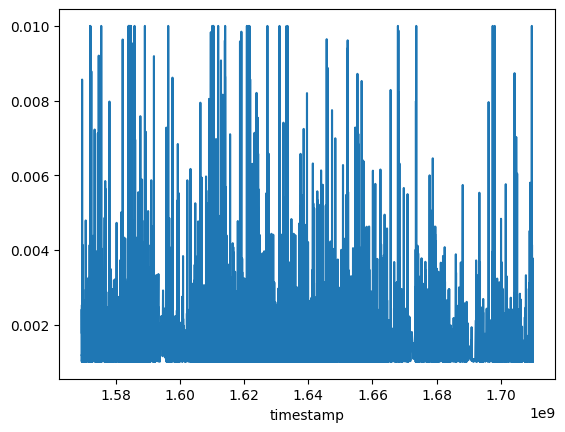

In [98]:
bdf.tp.plot()